In [143]:
import matplotlib.pyplot as plt
import utils, plotting, graph
import numpy as np
import seaborn as sns
from dataClass import nwbWrapper
from bootstrapPosteriors import data_for_state_model
import pickle
from tqdm import tqdm
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [144]:
def confidence_interval(data, confidence=0.95, axis=0):
    """Calculate the confidence interval based on standard deviation."""
    mean = np.mean(data, axis)
    std_dev = np.std(data, axis)
    z_score = 1.96  # for 95% confidence
    margin_of_error = z_score * (std_dev)
    return mean - margin_of_error, mean + margin_of_error

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 667.06it/s]


loading choice data:


100%|██████████| 943/943 [00:00<00:00, 2591.80it/s]


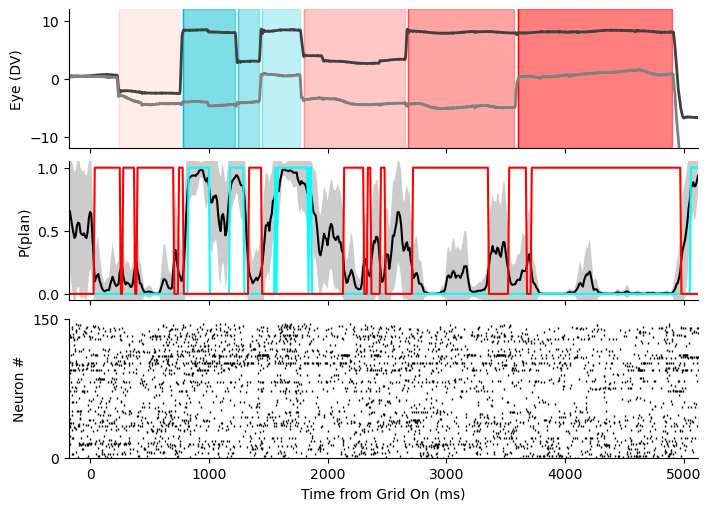

In [9]:
from matplotlib.patches import Rectangle
def fig3A():
        fnames = utils.get_filenames()
        data = nwbWrapper(fnames["london"][6], "OFC")
        post = pickle.load(open("data/bootstrapped_posteriors/london/London_TeleWorld_4x4_101124_spikes_state_posterior_boot.pkl", "rb"))
        choice_colors = plotting.interpolate_colors(color2="#ff0000", color1="#ffdbd9", num_colors=4)
        plan_colors = plotting.interpolate_colors(color2="#baf8ff", color1="#00bcd1", num_colors=4)
        fig, ax = plt.subplots(3, 1, figsize=(7, 5), constrained_layout=True, sharex=True)
        sns.despine()
        trial = 114
        ts = utils.trial_ts(data.trial_spikes[trial])
        eyes = data.trial_spikes[trial].eyes
        post_trace = utils.movmean(post["posteriors"][trial][:, :, 1].mean(axis=0), 1).flatten()
        t = np.arange(0, post_trace.shape[0] * 10, 10)

        def plot_fix_times(ax, data, trial):
                alpha=0.5
                fixations = data.fixation_df.copy()
                plans = fixations[(fixations.trial == trial) & (fixations.active_prob <= 0.2) & (fixations.duration > 50) & (fixations.node_on != fixations.target)]
                plan_on = (plans.start_time - plans.trial_start_time).values
                plan_off = (plans.stop_time - plans.trial_start_time).values

                ts = utils.trial_ts(data.trial_spikes[trial])
                choices = data.choice_df.query("trial == @trial").copy()
                choice_on = choices.fix_on.values - ts["ml_start_time"]
                choice_off = choices.fix_off.values - ts["ml_start_time"]
                
                for j in range(plans.shape[0]):
                        ax.axvline(plan_on[j], c=plan_colors[j], ls="-", lw=1)            
                        ax.axvspan(plan_on[j], plan_off[j], color=plan_colors[j], alpha=alpha)          
                for j in range(choices.shape[0]):
                        ax.axvline(choice_on[j], c=choice_colors[j], ls="-", lw=1)            
                        ax.axvspan(choice_on[j], choice_off[j], color=choice_colors[j], alpha=alpha)
        
        
        plot_fix_times(ax[0], data, trial)
        ax[0].plot(ts["t"], eyes[:,0], color=np.ones(3)*0.25, alpha=1, lw=2)
        ax[0].plot(ts["t"], eyes[:,1], color=np.ones(3)*0.5, alpha=1, lw=2)
        ax[0].set_ylim([-12, 12])
        xticks = np.arange(ts["start"], ts["start"] + 6000, 1000)
        tick_labels = (xticks - xticks[0]).astype(int)
        ax[0].set_xlim([ts["start"]-100, ts["start"] + 5100])
        ax[0].set_xticks(xticks, labels=tick_labels)
        ax[0].set_ylabel("Eye (DV)")

        ax[1].plot(t, post_trace, color="black", lw=1.5)
        ci95 = confidence_interval(post["posteriors"][trial][:, :, 1], confidence=0.95, axis=0)
        ci_bottom = utils.movmean(ci95[0], 1).flatten()
        ci_top = utils.movmean(ci95[1], 1).flatten()
        ax[1].plot(t, ci_bottom >= 0.5, c="cyan")
        ax[1].plot(t, ci_top <= 0.5, c="red")
        ax[1].fill_between(t, 
                        ci_bottom, ci_top, color="black", alpha=0.2, lw=0)
        ax[1].set_xlim([700, 6000])
        
        ax[1].set_ylim([-0.05, 1.05])
        ax[1].set_ylabel("P(plan)")
        
        X, y, _ = data_for_state_model(data)
        def get_weights(X, y):
                model = Pipeline([("zscore", StandardScaler()), ("clf", LogisticRegressionCV())])
                model.fit(X, y.ravel())
                return model.named_steps["clf"].coef_[0]
        weights = get_weights(X, y)
        idx = np.argsort(weights)
        spikes = data.trial_spikes[trial].neural[:, idx]
        n_x, n_y = np.where(spikes)
        ax[2].scatter(n_x, n_y, c="k", marker = "|", alpha=1, s=1, linewidth=1)
        ax[2].set_ylim([0, spikes.shape[1]])
        ax[2].set_xlabel("Time from Grid On (ms)")
        ax[2].set_yticks([0, 150])
        ax[2].set_ylabel("Neuron #")

fig3A()

In [88]:
def fig3B():
    fnames = utils.get_filenames()

    def where_plans_land(fname):
        data = nwbWrapper(fname, "OFC", to_load="bhv")
        plan_df = data.fixation_df.query("(duration >= 50) & (active_prob <= 0.2) & (node_on != target) & (trialerror ==0)").copy()
        n_plans = plan_df.shape[0]
        
        def node_on_path(row):
            nodes = np.array([int(node) for node in row.nodes.split(",")])
            if row.fix_node in nodes:
                return 2 # Path
            else:
                return 0 # Other
        
        plantype = plan_df.apply(lambda row: node_on_path(row), axis=1)
        plantype[plan_df.fix_node == plan_df.start] = 1 # Start
        plantype[plan_df.fix_node == plan_df.target] = 3 # Goal
        
        idx, counts = np.unique(plantype, return_counts=True)
        plantype_prob = np.zeros(4)
        plantype_prob[idx] = counts / n_plans
        return plantype_prob  # [Other, Start, Path, Goal]

    res = utils.iterate_subjects(fnames, where_plans_land)
    fig, ax = plt.subplots(1, 2, figsize=(10,5), sharey=True, sharex=True)
    for i, key in enumerate(res.keys()):
        res[key] = np.array(res[key])*100
        arr = res[key]
        ax[i].bar(np.arange(4), arr.mean(axis=0), yerr=arr.std(axis=0)/np.sqrt(arr.shape[0]), facecolor="none", edgecolor="k")
        ax[i].set_ylim([0, 40])
        ax[i].set_title("Subject %s" % key[0].capitalize())
        ax[i].set_xticks([0, 1, 2, 3], labels=["Other", "Start", "Path", "Goal"])
        sns.despine()
    ax[0].set_ylabel("Planning fixations (%)")
    return res

data3B = fig3B()    

Processing bart:  12%|█▎        | 1/8 [00:03<00:23,  3.30s/it]


KeyboardInterrupt: 

In [145]:
def fig3C():
    fnames = utils.get_filenames()
    
    def when_plans_occur(fname):
        data = nwbWrapper(fname, "OFC", to_load="bhv")
        plan_df = data.fixation_df.query("(duration >= 50) & (active_prob <= 0.2) & (node_on != target) & (trialerror ==0)").copy()
        trials = data.trial_df.query("trialerror == 0").trial.values
        plan_per_step_prob = np.zeros([len(trials), 6])
        for i, trial in enumerate(trials):
            step_on = plan_df.query("trial == @trial").step_on.values
            step_on[step_on >= 5] = 5
            step_idx = np.unique(step_on).astype(int)
            plan_per_step_prob[i, step_idx] += 1
            
        steps_by_trial = data.choice_df.query("trialerror == 0").step.values
        steps_by_trial[steps_by_trial >= 5] = 5
        _, count_by_step = np.unique(steps_by_trial, return_counts=True)
        
        plan_per_step_prob = plan_per_step_prob.sum(axis=0) / count_by_step
        return plan_per_step_prob
    
    res = utils.iterate_subjects(fnames, when_plans_occur)

    fig, ax = plt.subplots(1, 2, figsize=(10,5), sharex=True, sharey=True)
    linefunc = lambda reg, x: reg.coef[0] + x * reg.coef[1]
    from pingouin import linear_regression
    for j, key in enumerate(res):
        res[key] = np.array(res[key])
        reg_X = np.tile(np.arange(6), res[key].shape[0]) 
        reg_Y = res[key].flatten()
        reg_model = linear_regression(reg_X, reg_Y, add_intercept=True)
        ax[j].scatter(reg_X, reg_Y, alpha=0.5, c="k")
        
        ax[j].plot(np.array([0, 5]), linefunc(reg_model, np.array([0, 5])), c="k", lw=1)
        print("subject %s: beta = %.2f, p = %.2e" % (key[0].capitalize(), reg_model.coef[1], reg_model.pval[1]))
        ax[j].set_title("Subject %s" % key[0].capitalize())
        ax[j].set_xlabel("Trajectory Step")
        ax[j].set_xticks(np.arange(6), labels=[0, 1, 2, 3, 4, "5+"])
    ax[0].set_ylabel("P(saccade)")
    
    sns.despine()
    return res
        

In [142]:
6.1e-3

0.0061

Processing london: 100%|██████████| 7/7 [00:34<00:00,  4.93s/it]

subject B: b = -0.07, p = 1.36e-16
subject L: b = -0.07, p = 7.36e-16


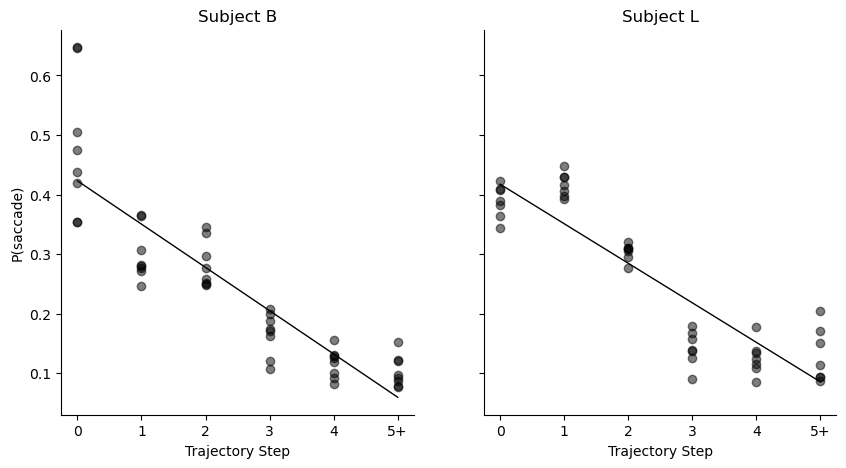

In [72]:
res = fig3C()

In [86]:
def suppfig3():
    fnames = utils.get_filenames()
    
    def where_plans_during_tele(fname):
        data = nwbWrapper(fname, "OFC", to_load="bhv")
        plan_df = data.fixation_df.query("(duration >= 100) & (active_prob <= 0.2) & (node_on != target) & (trialerror ==0)").copy()
        trials = data.trial_df.query("trialerror == 0").trial.values
        plan_per_step_prob = np.zeros([len(trials), 6])
        
        plan_by_tele_prob = np.zeros(3)
        tele_trialtype_counts = np.zeros(3)
        for i, trial in enumerate(trials):
            start, target = data.trial_df.query("trial == @trial").loc[:, ["start", "target"]].values[0]
            Dd = graph.distance(start, target, type="space") - graph.distance(start, target, type="graph")
            Dd = np.clip(Dd, 0, 2)
            n_saccades = plan_df.query("(trial == @trial) & (step_on <= 1)").shape[0]
            if n_saccades > 0:
                plan_by_tele_prob[Dd] += 1
            tele_trialtype_counts[Dd] += 1
        
        plan_by_tele_prob = plan_by_tele_prob/tele_trialtype_counts
        
        
        return plan_by_tele_prob
    
    res = utils.iterate_subjects(fnames, where_plans_during_tele)
    fig, ax = plt.subplots(1, 2, figsize=(5, 5), sharex=True, sharey=True)
    from scipy.stats import tukey_hsd
    for i, key in enumerate(res):
        res[key] = np.array(res[key])
        print(tukey_hsd(res[key][:,0], res[key][:,1], res[key][:,2]))
        ax[i].bar(np.arange(3), res[key].mean(axis=0), yerr=res[key].std(axis=0)/np.sqrt(res[key].shape[0]), facecolor="none", edgecolor="k")
        sns.despine()    
        ax[i].set_title("Subject %s" % key[0].capitalize())
        ax[i].set_xticks([0, 1, 2], labels=["0", "1", "3"])
        ax[i].set_xlabel("Steps Saved")
        ax[i].set_ylabel("P(planning saccade)")
    return res
    

Processing london: 100%|██████████| 7/7 [00:44<00:00,  6.29s/it]


Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.197     0.002    -0.325    -0.070
 (0 - 2)      0.008     0.988    -0.120     0.135
 (1 - 0)      0.197     0.002     0.070     0.325
 (1 - 2)      0.205     0.002     0.077     0.333
 (2 - 0)     -0.008     0.988    -0.135     0.120
 (2 - 1)     -0.205     0.002    -0.333    -0.077

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.159     0.001    -0.246    -0.072
 (0 - 2)      0.172     0.000     0.085     0.259
 (1 - 0)      0.159     0.001     0.072     0.246
 (1 - 2)      0.331     0.000     0.244     0.417
 (2 - 0)     -0.172     0.000    -0.259    -0.085
 (2 - 1)     -0.331     0.000    -0.417    -0.244



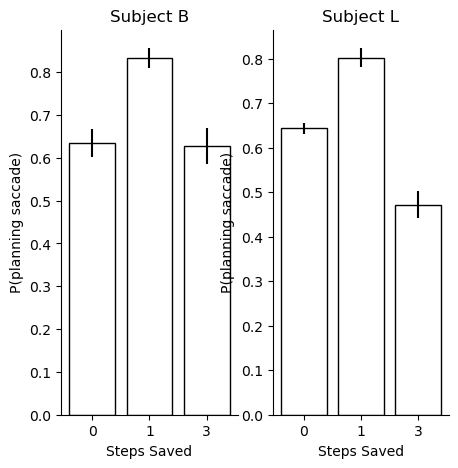

In [87]:
res = suppfig3()

In [190]:
def finish_action_prev(codes):
    num = codes["numbers"]
    times = codes["times"]
    t_grid_on = times[num == 30]
    t_finish_view = times[num == 82]
    t_finish_action = times[num == 92]
    t_action_start = t_finish_action - 300
    t_finish_action_all = np.insert(t_finish_action, 0, t_finish_view[0])
    t_finish_action_prev = np.insert(t_finish_action_all[:-1], 0, t_grid_on)
    return t_finish_action_prev

def append_rts(data):
    trials = data.choice_df.trial.unique()
    prev_action_offsets = []
    for trial in trials:
        choices = data.choice_df.query("trial == @trial").copy()
        codes = dict(times=data.trial_spikes[trial].ets, numbers = data.trial_spikes[trial].evs)
        prev_action_offsets.append(finish_action_prev(codes))
    data.choice_df["prev_action_offset"] = np.hstack(prev_action_offsets)
    data.choice_df["rt"] = data.choice_df.fix_on - data.choice_df.prev_action_offset
    

def planning_effect_on_value(fname):
    
    data =nwbWrapper(fname, "OFC")
    append_rts(data)
    trials = data.trial_df.query("trialerror == 0").trial.values
    prev_plan = []
    any_plan = []
    #rts = []
    for trial in trials:
        choices = data.choice_df.query("trial == @trial").copy()
        codes = dict(times=data.trial_spikes[trial].ets, numbers = data.trial_spikes[trial].evs)
        #rts.append(utils.get_rts(codes))
        prev_plan_in_trial = np.zeros(choices.shape[0])
        any_plan_in_trial = np.zeros(choices.shape[0])
        plans = data.fixation_df.query("(duration >= 50) & (active_prob <= 0.2) & (node_on != target) & (trial == @trial)").copy()
        for i, choice in choices.reset_index().iterrows():
            prev_fix = plans.query("(fix_node == %i) & (step_off <= %i)" % (choice.node, choice.step)).loc[:, ("fix_node")]
            any_prev_fix = plans.query("(step_off <= %i)" % (choice.step)).loc[:, ("fix_node")]
            if prev_fix.shape[0] > 0:
                prev_plan_in_trial[i] = 1
            if any_prev_fix.shape[0] > 0:
                any_plan_in_trial[i] = 1
        prev_plan.append(prev_plan_in_trial)
        any_plan.append(any_plan_in_trial)
        
    prev_plan = np.hstack(prev_plan).flatten()
    any_plan = np.hstack(any_plan).flatten()
    #rts = np.hstack(rts).flatten()
    #rt_mod = rts + (data.choice_df.fix_on - data.choice_df.start_time - 500)
    rts = data.choice_df.rt.values
    step = data.choice_df.step.values
    from sklearn.model_selection import KFold
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    X = data.choice_spikes[:, 500:800, :].mean(axis=1)
    y = data.choice_df.graph_distance.values
    y[y >= 4] = 4
    y = 4 - y
    
    pred = np.zeros(y.shape)
    for train, test in tqdm(cv.split(X)):
        model = Pipeline([("zscore", StandardScaler()), ("lasso", LassoCV())])
        model.fit(X[train], y[train])
        pred[test] = model.predict(X[test])

    return pd.DataFrame(dict(value=y, lasso_estimate=pred, prev_plan=prev_plan, rt=rts, any_plan = any_plan, step=step))
    
    
from pingouin import ancova
def fig3D():
    fnames = utils.get_filenames()
    res = utils.iterate_subjects(fnames, planning_effect_on_value)
    
    return res

In [191]:
res = fig3D()

Processing bart:   0%|          | 0/8 [00:00<?, ?it/s]

loading trial data:
loading trials:


100%|██████████| 563/563 [00:00<00:00, 604.87it/s]


loading choice data:


100%|██████████| 1383/1383 [00:01<00:00, 1357.16it/s]
10it [00:00, 13.86it/s]
Processing bart:  12%|█▎        | 1/8 [00:18<02:07, 18.25s/it]

...

100%|██████████| 2434/2434 [00:01<00:00, 1855.08it/s]
10it [00:00, 18.62it/s]
Processing london:  86%|████████▌ | 6/7 [03:05<00:30, 30.93s/it]

loading trial data:
loading trials:


100%|██████████| 943/943 [00:01<00:00, 632.22it/s]


loading choice data:


100%|██████████| 2545/2545 [00:01<00:00, 1397.86it/s]
10it [00:00, 14.13it/s]
Processing london: 100%|██████████| 7/7 [03:37<00:00, 31.09s/it]


Subject B ANCOVA results:
      Source           SS     DF            F         p-unc       np2
0  prev_plan    34.483633      1   161.865222  6.838900e-37  0.010577
1      value   811.664027      1  3809.928611  0.000000e+00  0.201042
2         rt     0.072931      1     0.342337  5.584923e-01  0.000023
3   Residual  3225.626065  15141          NaN           NaN       NaN
Subject L ANCOVA results:
      Source           SS     DF            F          p-unc       np2
0  prev_plan   146.522737      1   535.023560  1.396338e-116  0.030335
1      value  1968.564144      1  7188.155364   0.000000e+00  0.295929
2         rt    35.421503      1   129.340601   7.313512e-30  0.007506
3   Residual  4683.591587  17102          NaN            NaN       NaN


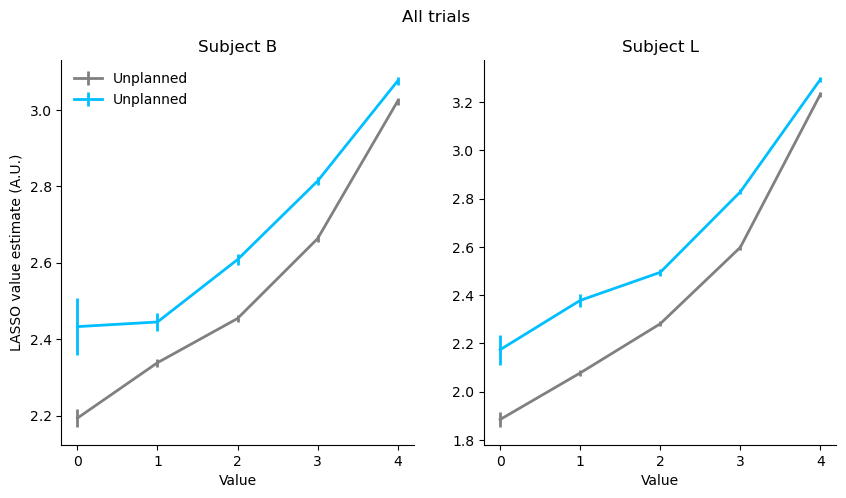

In [189]:
fig, ax = plt.subplots(1, 2, figsize=(10,5), sharex=True)
for j, key in enumerate(res):
    df = pd.concat(res[key])
    to_plot = df.groupby(["prev_plan", "value"]).agg(["mean", "sem"])
    X = np.arange(5)
    colors = [[0.5, 0.5, 0.5], "deepskyblue"]
    for k in range(2):
        Y = to_plot["lasso_estimate"]["mean"][k]
        Y_err = to_plot["lasso_estimate"]["sem"][k]
        ax[j].errorbar(X, Y, yerr=Y_err, marker='none', color = colors[k], lw=2, label="Unplanned")
    #to_plot = df.query("prev_plan == 1").groupby(["value"]).agg(["mean", "sem"])
    #X = to_plot.index
    #Y = to_plot["lasso_estimate"]["mean"]
    #Y_err = to_plot["lasso_estimate"]["sem"]
    #ax[j].errorbar(X, Y, yerr=Y_err, marker='none', color = "deepskyblue", lw=2, label="Planned")
    
    ax[j].set_title("Subject %s" % key[0].capitalize())
    ax[j].set_xlabel("Value")
    print("Subject %s ANCOVA results:" % key[0].capitalize())
    print(ancova(data=df, dv="lasso_estimate", covar=["value", "rt"], between="prev_plan"))
ax[0].set_ylabel("LASSO value estimate (A.U.)")
ax[0].legend(frameon=False)
fig.suptitle("All trials")
sns.despine()


,Source,SS,DF,F,p-unc,np2
0,prev_plan,39.111427,1,183.595935,1.388969e-41,0.011980
1,value,866.616939,1,4068.052755,0.000000e+00,0.211767
2,Residual,3225.698996,15142,NaN,NaN,NaN


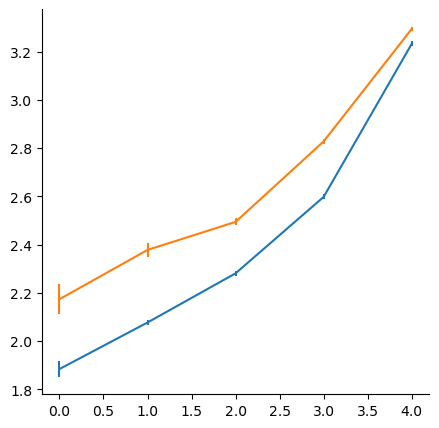